## Imports


In [12]:
import os
import random
import numpy as np
import pandas as pd
import torch
import kagglehub
import inspect
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)


import warnings
warnings.filterwarnings("ignore")

## End-to-End Transformer-Based Résumé Scoring Pipeline

In [13]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Download + locate CSV
dataset_dir = kagglehub.dataset_download("mdtalhask/ai-powered-resume-screening-dataset-2025")
csv_files = [f for f in os.listdir(dataset_dir) if f.lower().endswith(".csv")]
if not csv_files:
    raise FileNotFoundError(f"No CSV file found in {dataset_dir}. Files: {os.listdir(dataset_dir)}")

csv_path = os.path.join(dataset_dir, csv_files[0])
print("Using dataset file:", csv_path)

# Load data
df = pd.read_csv(csv_path)

# Validate required columns (structured version)
required_cols = {
    "Skills",
    "Experience (Years)",
    "Education",
    "Certifications",
    "Projects Count",
    "AI Score (0-100)",
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found columns: {list(df.columns)}")

# Clean target
df["AI Score (0-100)"] = pd.to_numeric(df["AI Score (0-100)"], errors="coerce")
df = df.dropna(subset=["AI Score (0-100)"]).copy()
df = df[(df["AI Score (0-100)"] >= 0.0) & (df["AI Score (0-100)"] <= 100.0)].copy()

def safe(x):
    return "" if pd.isna(x) else str(x)

def create_resume_text(row):
    # Natural separators; avoid "nan"
    return (
        f"Skills: {safe(row['Skills'])}. "
        f"Experience: {safe(row['Experience (Years)'])} years. "
        f"Education: {safe(row['Education'])}. "
        f"Certifications: {safe(row['Certifications'])}. "
        f"Projects: {safe(row['Projects Count'])}."
    )

df["resume_text"] = df.apply(create_resume_text, axis=1)

texts = df["resume_text"].tolist()

# Normalise 0–100 to 0–1 for training
labels_0_1 = (df["AI Score (0-100)"] / 100.0).astype(float).tolist()

# Train/Val/Test split (avoid test leakage)
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels_0_1, test_size=0.30, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=SEED
)

# Tokeniser
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

class ResumeDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_length,
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor([self.labels[idx]], dtype=torch.float)  # shape [1]
        return item

train_dataset = ResumeDataset(X_train, y_train, tokenizer, max_length=256)
val_dataset   = ResumeDataset(X_val,   y_val,   tokenizer, max_length=256)
test_dataset  = ResumeDataset(X_test,  y_test,  tokenizer, max_length=256)

# Model (explicit regression)
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1)
model.config.problem_type = "regression"

def compute_metrics(eval_pred):
    preds = eval_pred.predictions
    if isinstance(preds, tuple):
        preds = preds[0]

    preds_0_1 = preds.reshape(-1)
    labels_0_1_arr = eval_pred.label_ids.reshape(-1)

    preds_0_100  = preds_0_1 * 100.0
    labels_0_100 = labels_0_1_arr * 100.0

    rmse = float(np.sqrt(mean_squared_error(labels_0_100, preds_0_100)))
    mae  = float(mean_absolute_error(labels_0_100, preds_0_100))
    r2   = float(r2_score(labels_0_100, preds_0_100))
    return {"rmse": rmse, "mae": mae, "r2": r2}

# Training arguments (fix: allow saving + eval so best model can load)
ta_params = inspect.signature(TrainingArguments).parameters
eval_kw = "evaluation_strategy" if "evaluation_strategy" in ta_params else "eval_strategy"

training_args = TrainingArguments(
    output_dir="./results_resume_regression",
    num_train_epochs=10,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    **{eval_kw: "epoch"},
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    weight_decay=0.01,
    logging_strategy="epoch",
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # validation set
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

# Final unbiased test evaluation
test_metrics = trainer.evaluate(test_dataset)
print("\nFINAL TEST METRICS (0–100 scale):")
print(test_metrics)

# Save model + tokenizer
SAVE_DIR = "./saved_model_resume_regression"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"\nSaved model to: {SAVE_DIR}")

Using dataset file: /root/.cache/kagglehub/datasets/mdtalhask/ai-powered-resume-screening-dataset-2025/versions/1/AI_Resume_Screening.csv


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Rmse,Mae,R2
1,0.051750,0.004980,7.057001,5.501709,0.898808
2,0.008952,0.003883,6.231418,5.104590,0.921100
3,0.005474,0.003270,5.718327,4.066943,0.933558
4,0.003359,0.001145,3.383161,2.520215,0.976743
5,0.002655,0.000760,2.757220,2.186157,0.984553
6,0.002295,0.001122,3.349526,2.465820,0.977203
7,0.002103,0.000480,2.191043,1.583105,0.990245
8,0.001769,0.000311,1.763954,1.290332,0.993678
9,0.001629,0.000416,2.039679,1.587305,0.991547
10,0.001441,0.000357,1.889029,1.380469,0.992749


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


FINAL TEST METRICS (0–100 scale):
{'eval_loss': 0.00034099369077011943, 'eval_rmse': 1.8466017054528956, 'eval_mae': 1.378088355064392, 'eval_r2': 0.9933340549468994, 'eval_runtime': 0.3846, 'eval_samples_per_second': 519.998, 'eval_steps_per_second': 65.0, 'epoch': 10.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved model to: ./saved_model_resume_regression


## Test Set Predictions for Model Evaluation

In [3]:
predictions = trainer.predict(test_dataset)

preds_0_1 = predictions.predictions
if isinstance(preds_0_1, tuple):
    preds_0_1 = preds_0_1[0]
preds_0_1 = preds_0_1.reshape(-1)

true_0_1 = predictions.label_ids.reshape(-1)

preds = preds_0_1 * 100.0
true_labels = true_0_1 * 100.0

## Predicted vs Actual AI Scores (Large Sample Visualisation)

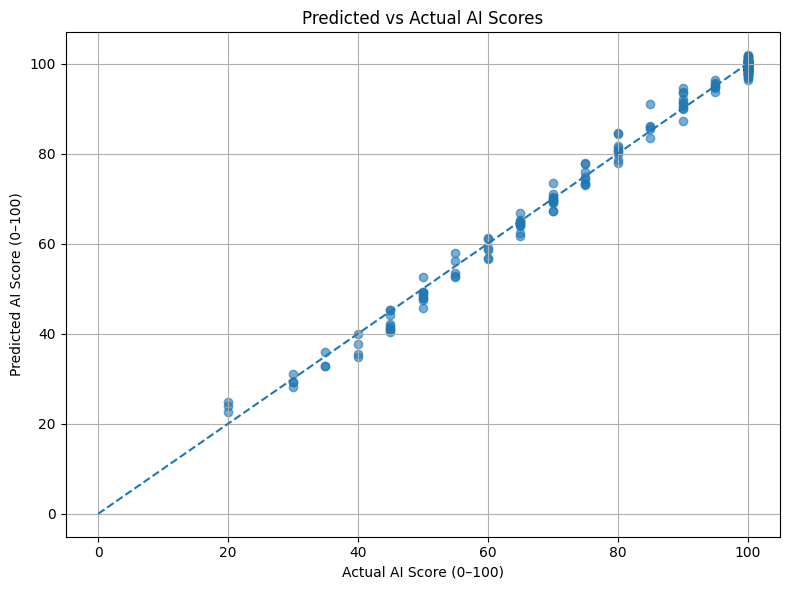

In [4]:
n = 1000
limited_preds = preds[:n]
limited_labels = true_labels[:n]

plt.figure(figsize=(8, 6))
plt.scatter(limited_labels, limited_preds, alpha=0.6)
plt.plot([0, 100], [0, 100], linestyle="--")  # y = x
plt.xlabel("Actual AI Score (0–100)")
plt.ylabel("Predicted AI Score (0–100)")
plt.title("Predicted vs Actual AI Scores")
plt.grid(True)
plt.tight_layout()
plt.show()


## Predicted and Actual AI Scores Across Samples


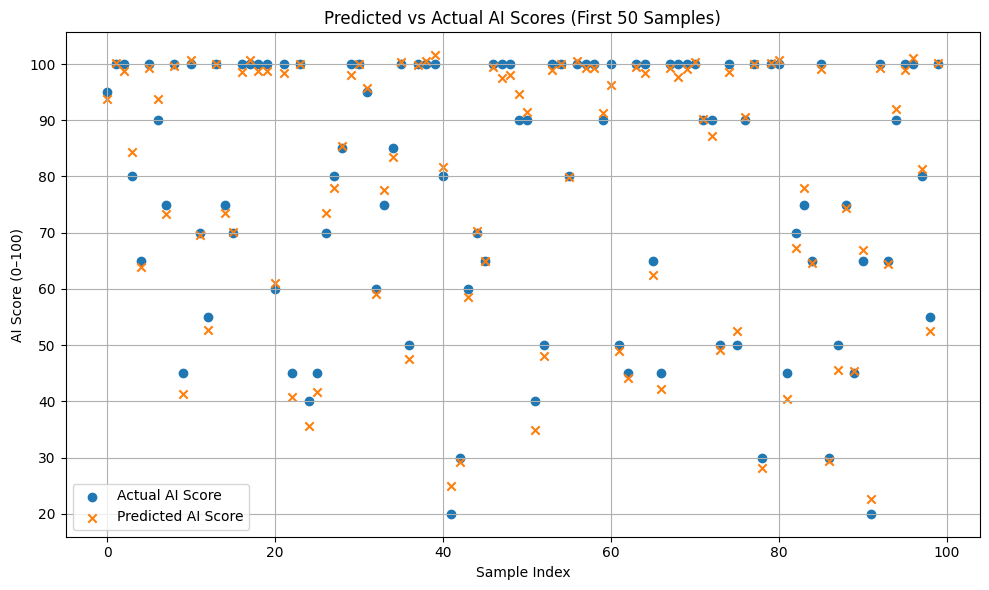

In [7]:
n = 100
limited_preds = preds[:n]
limited_labels = true_labels[:n]

plt.figure(figsize=(10, 6))
plt.scatter(range(n), limited_labels, label="Actual AI Score", marker="o")
plt.scatter(range(n), limited_preds, label="Predicted AI Score", marker="x")
plt.xlabel("Sample Index")
plt.ylabel("AI Score (0–100)")
plt.title("Predicted vs Actual AI Scores (First 50 Samples)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Single Résumé Inference Example

In [10]:


SAVE_DIR = "./saved_model_resume_regression"

model = BertForSequenceClassification.from_pretrained(SAVE_DIR)
tokenizer = BertTokenizerFast.from_pretrained(SAVE_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Build input in the SAME structured style used in training
text = (
    "Skills: Python, TensorFlow, PyTorch, NLP. "
    "Experience: 10 years. "
    "Education: M.Tech. "
    "Certifications: AWS Certification. "
    "Projects: 100."
)

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=256
)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    pred_0_1 = model(**inputs).logits.squeeze().item()

print(f"Predicted AI Score: {pred_0_1 * 100.0:.2f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Predicted AI Score: 98.35
